# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

In [ ]:
#From a data perspective, this translates to a regression problem. We will develop a predictive model where the target variable is the price of a used car. The features will consist of various car attributes (e.g., make, model, year, condition, mileage, transmission, fuel type, etc.). Our goal is to build a model that can accurately predict the price of a used car given its characteristics, thereby identifying which features have the most significant impact on price and their relative importance. This will allow us to quantify the relationship between car features and their market value.



### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [2]:
import pandas as pd
from google.colab import files

# Upload the file from your local hard drive
uploaded = files.upload()

# The file name is 'vehicles.csv'
df = pd.read_csv('vehicles.csv')

Saving vehicles.csv to vehicles.csv


In [3]:
#Load the dataset into a pandas DataFrame. Since the file is uploaded directly to Colab, we would use files.upload() to initiate the upload process and then pd.read_csv() to load the data from the uploaded file.
#Display the first few rows of the DataFrame (df.head()) to get a quick overview of the data structure and initial columns.
#Check the data types of each column (df.info()) to identify if any columns are not in their expected format (e.g., numbers stored as strings).
#Examine the number of rows and columns (df.shape) to understand the dataset's size.

#Generate descriptive statistics for numerical columns (df.describe()) to understand the central tendency, dispersion, and shape of the data's distribution. This will help identify potential outliers or unusual ranges. For instance, price or odometer values that are extremely high or low.
#Explore the unique values and their counts for categorical columns (df['column_name'].value_counts()). This helps in understanding the diversity within categories and identifying potential inconsistencies or typos (e.g., "sedan" vs. "Sedan").
#Visualize the distribution of key variables.
#For numerical variables like price and odometer, use histograms (.hist()) or box plots (sns.boxplot()) to observe their distributions, skewness, and presence of outliers.
#For categorical variables, use bar plots (sns.countplot()) to visualize the frequency of each category.
#Explore relationships between features and the target variable (price). For example, scatter plots (sns.scatterplot(x='odometer', y='price', data=df)) can show if price decreases with odometer readings. Box plots can show price distribution across different manufacturer or condition categories.

#Data Quality Verification:
#Missing Values: Identify columns with missing values (df.isnull().sum()). Determine the percentage of missing values in each column to decide on appropriate handling strategies (e.g., imputation, removal).
#Duplicate Records: Check for and quantify duplicate rows (df.duplicated().sum()) that might skew analysis.
#Inconsistent Data Entries: Look for variations in categorical data (e.g., "automatic" vs "Automatic" for transmission). This might require standardization.
#Outliers: Based on descriptive statistics and visualizations, identify extreme values in numerical columns that could be data entry errors or genuine but influential outliers. For instance, a car with 1 mile on the odometer and a very low price might indicate an error.
#Plausibility Checks: Use domain knowledge to check for logical inconsistencies. For example, a car's year being in the future, or an odometer reading that's unrealistically low for an old car.


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


current_year = 2025
df['car_age'] = current_year - df['year']

# Log transform the target variable
if 'price' in df.columns:
    df['price_log'] = np.log1p(df['price'])
else:
    print("Warning: 'price' column not found. Cannot create 'price_log'. Please check your dataset.")


# Define categorical and numerical features.
categorical_features = ['manufacturer', 'model', 'condition', 'cylinders', 'fuel',
                        'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
numerical_features = ['odometer', 'car_age'] # Add 'mileage_per_year' if engineered

# Filter categorical and numerical features to ensure they exist in the DataFrame
categorical_features = [col for col in categorical_features if col in df.columns]
numerical_features = [col for col in numerical_features if col in df.columns]


# Create preprocessor for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Define columns to drop, ensuring they exist in the DataFrame before dropping
columns_to_drop = ['price', 'price_log', 'year']

optional_columns_to_drop = ['url', 'image_url', 'description', 'region'] # These were the ones causing error
for col in optional_columns_to_drop:
    if col in df.columns:
        columns_to_drop.append(col)

# Ensure 'price_log' exists before attempting to use it as target
if 'price_log' not in df.columns:
    print("Error: 'price_log' column is missing, cannot proceed with model training. Please ensure 'price' column is present and transformed.")

# Define features (X) and target (y)
X = df.drop(columns=columns_to_drop, axis=1) # Use 'columns' argument for clarity
y = df['price_log']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

Saving vehicles.csv to vehicles (4).csv
Original dataset size: 426880 rows
Sampled dataset size: 21344 rows

--- Data Understanding: Initial Visualizations ---


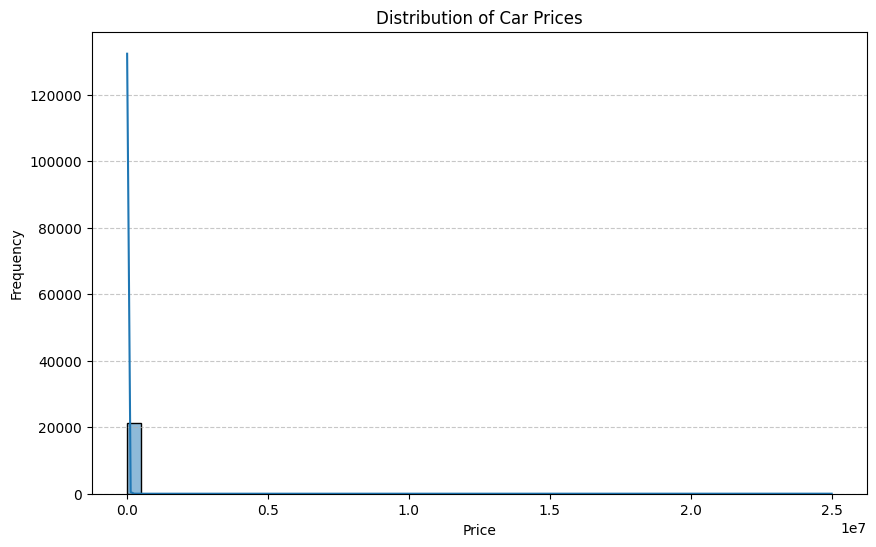

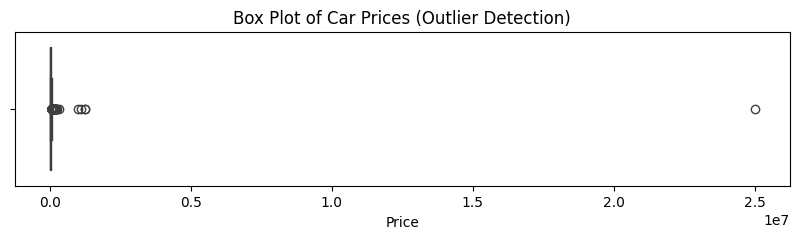

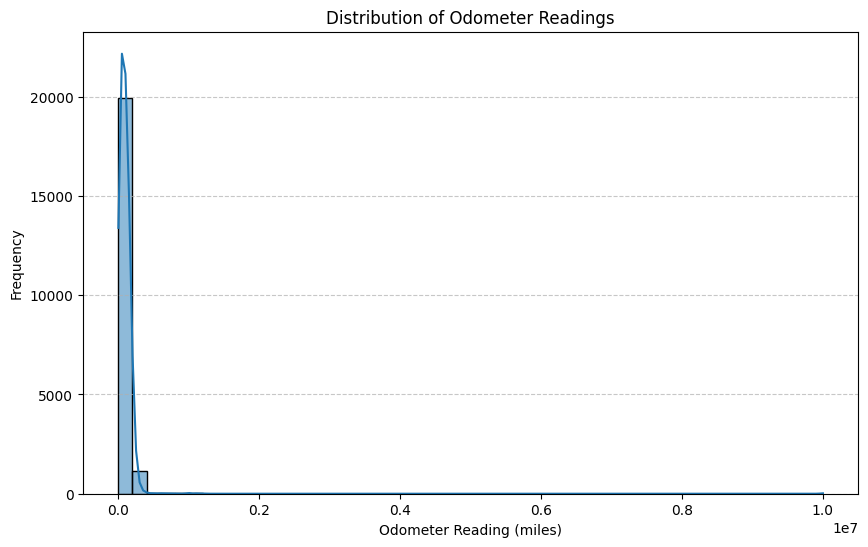

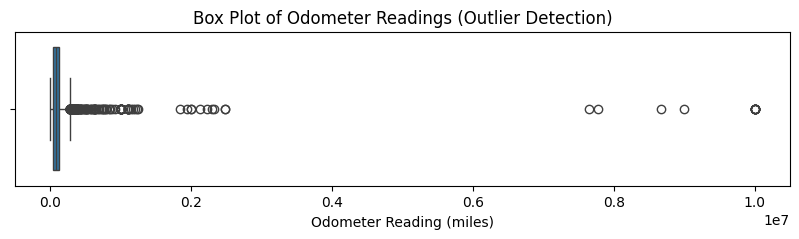

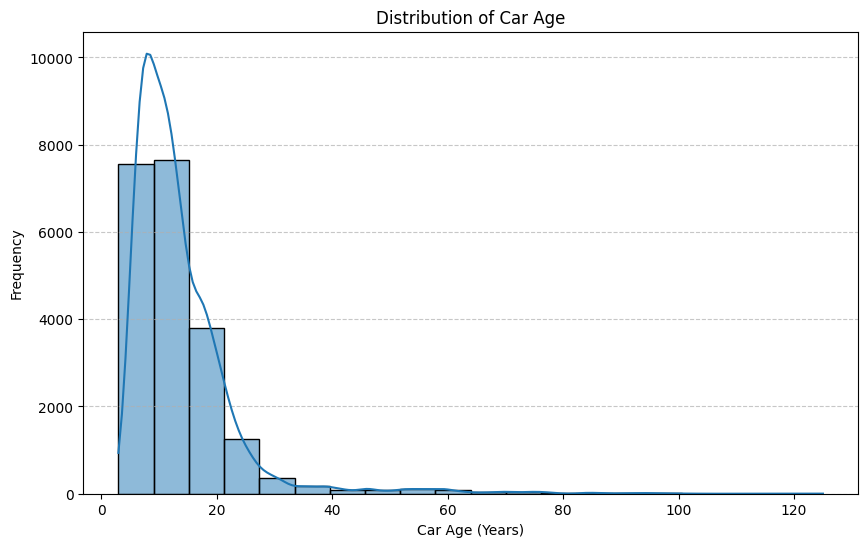

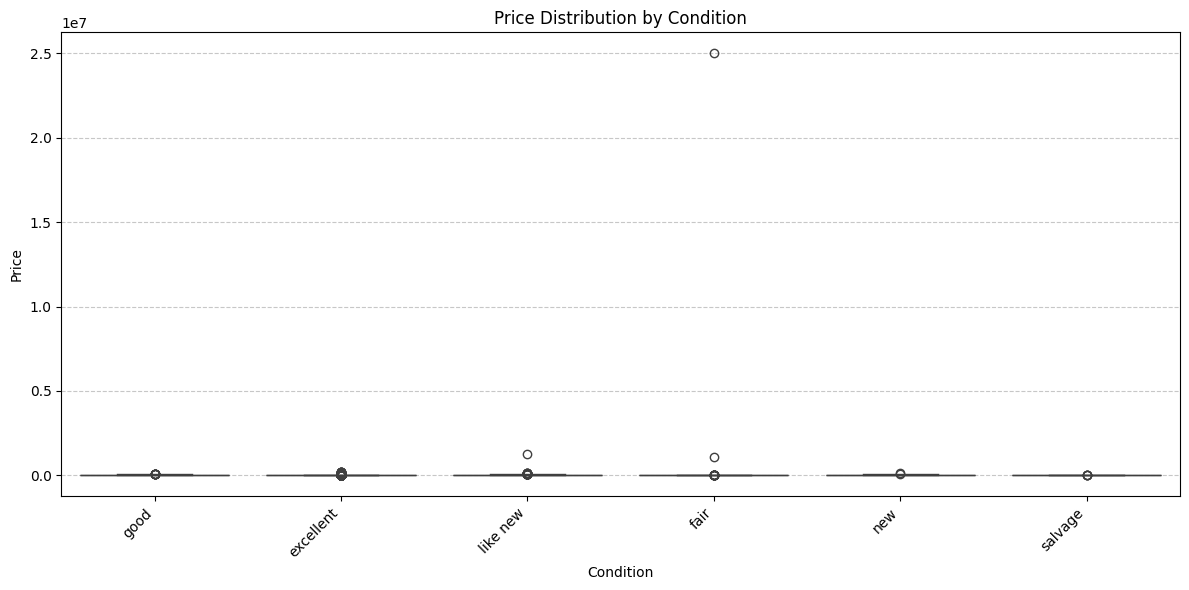

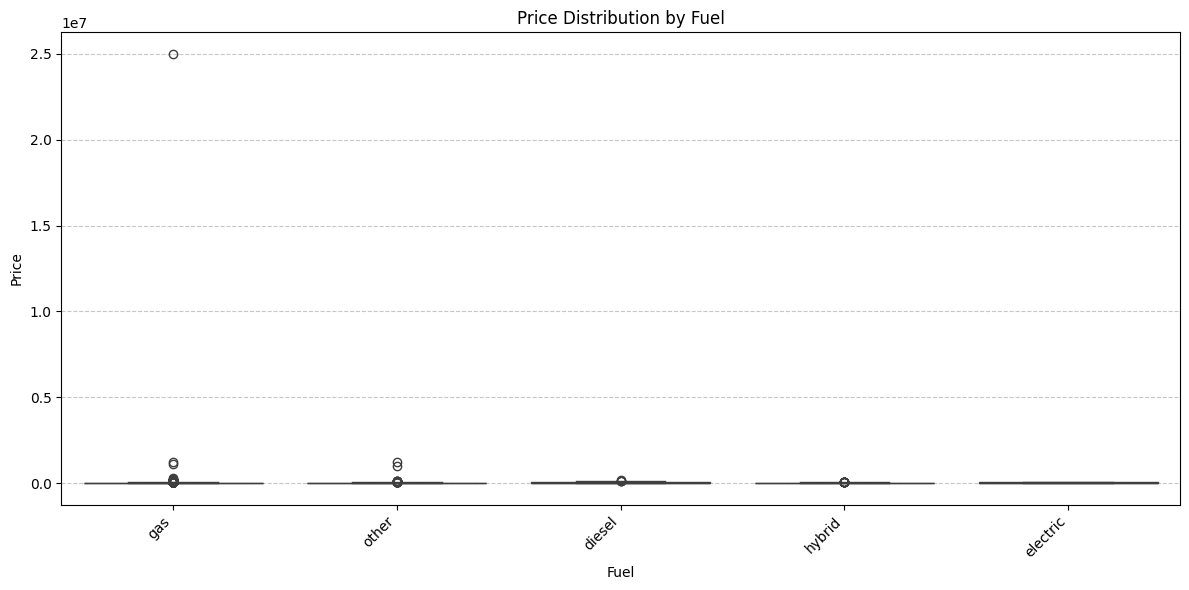

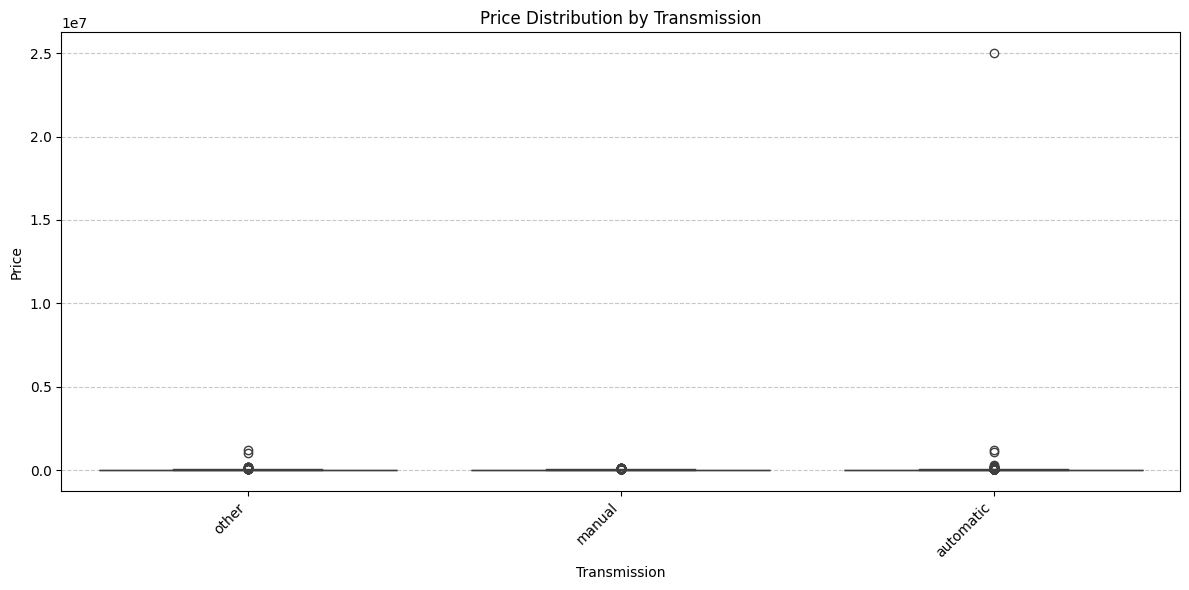

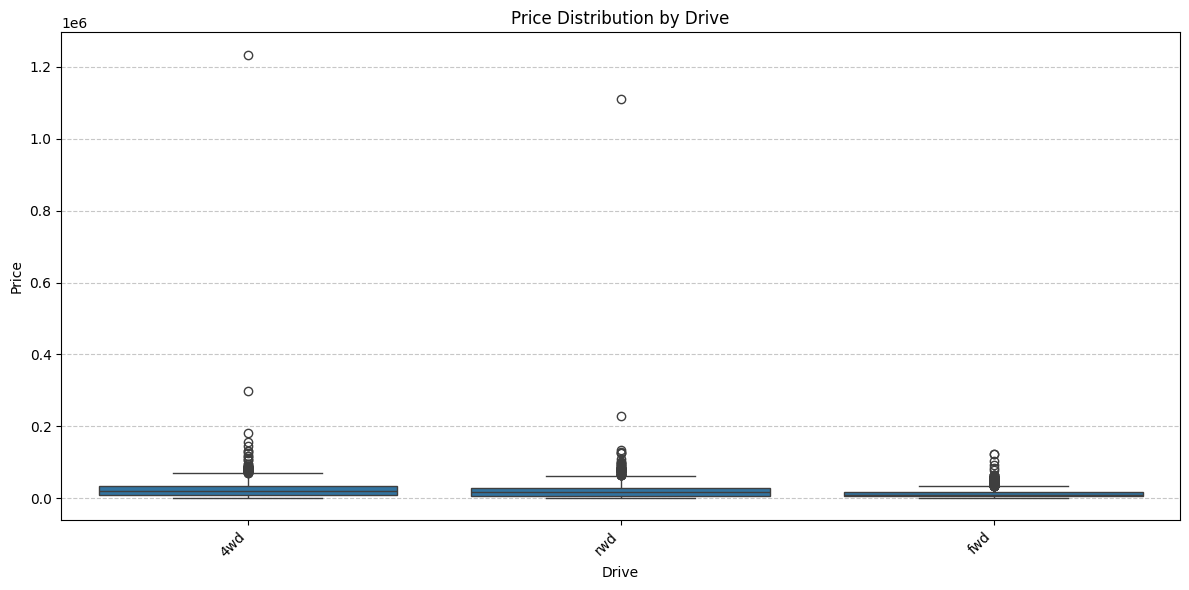

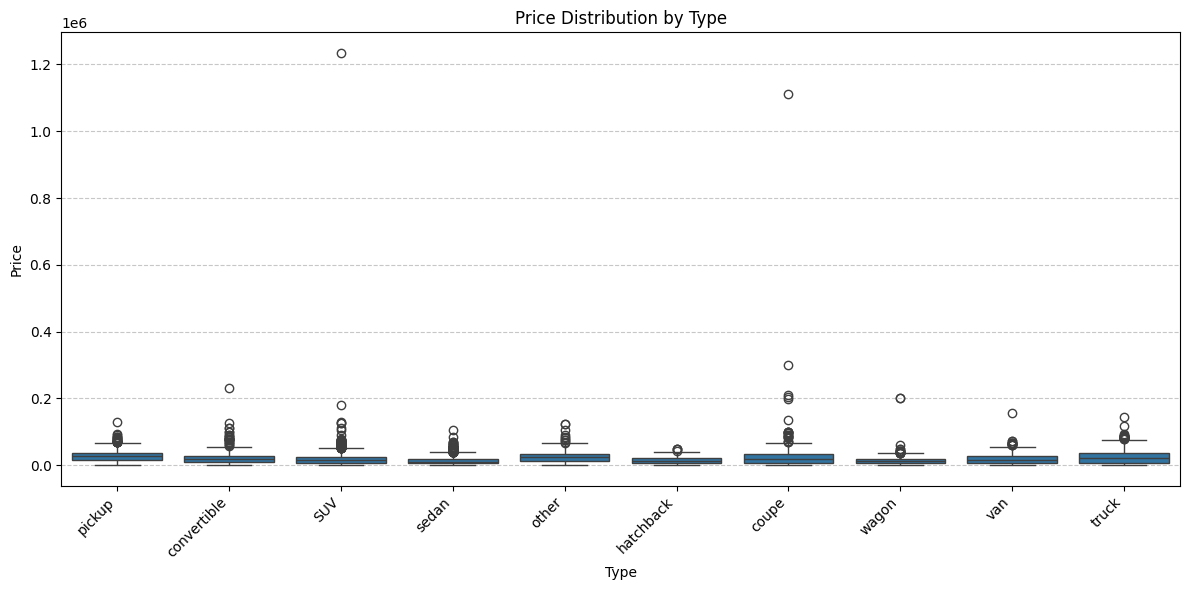

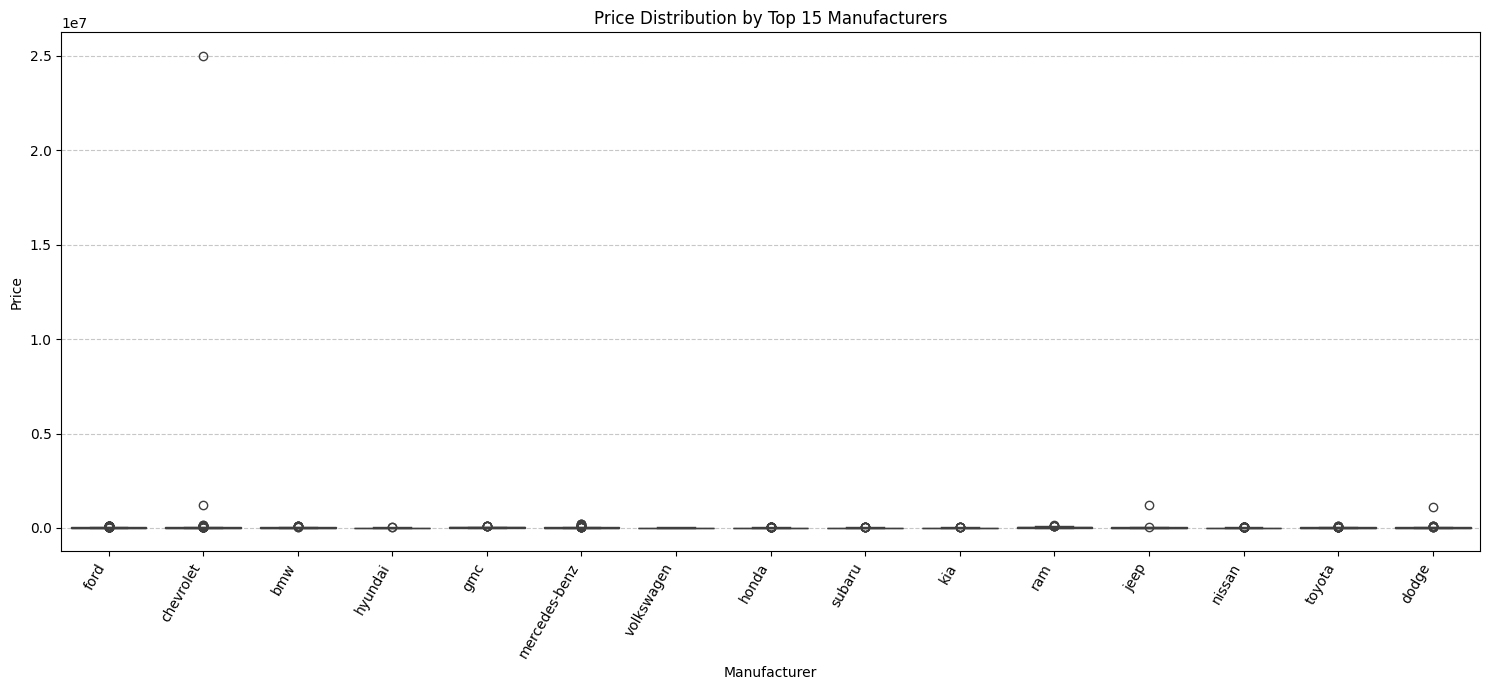

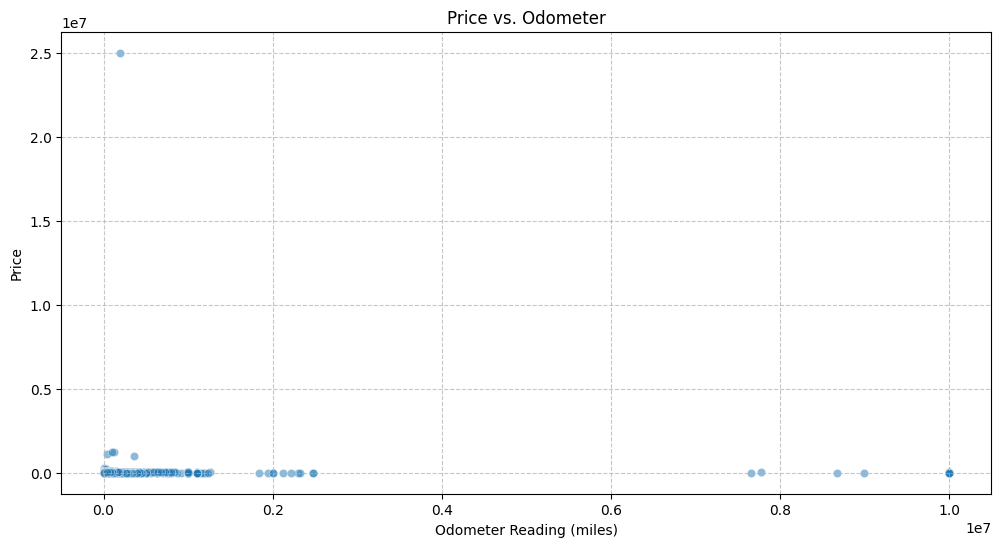

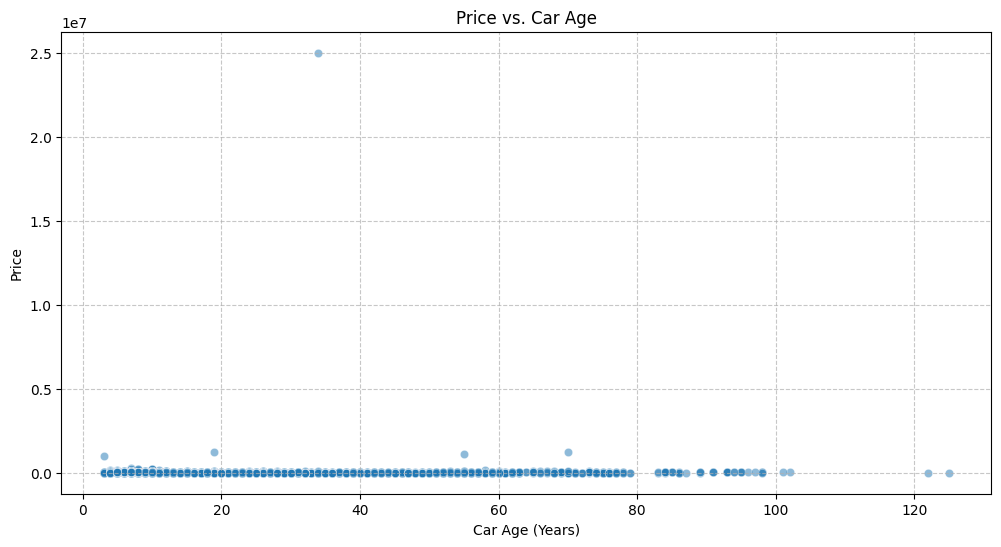


--- End of Data Understanding Visualizations ---
Training Linear Regression...
No specific hyperparameters for Linear Regression. Training pipeline directly.
Finished Linear Regression. MAE: 13808.82, RMSE: 37554.33, R2: -5.13

Training Ridge...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters for Ridge: {'regressor__alpha': 10.0}
Finished Ridge. MAE: 11193.41, RMSE: 16624.26, R2: -0.20

Training Lasso...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters for Lasso: {'regressor__alpha': 0.001}
Finished Lasso. MAE: 11359.33, RMSE: 16813.45, R2: -0.23

Training Decision Tree...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best parameters for Decision Tree: {'regressor__max_depth': 20}
Finished Decision Tree. MAE: 9751.89, RMSE: 28295.90, R2: -2.48

Training Random Forest...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters for Random Forest: {'regressor__max_depth': 20, 'regressor__n_estimators': 1

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # Import for visualizations
import seaborn as sns          # Import for visualizations

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# --- Data Loading ---
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('vehicles.csv')

# --- Applying More Aggressive Sampling to Speed Up Processing ---
print(f"Original dataset size: {len(df)} rows")
# Reducing sample to 5% for much faster execution
df_sample = df.sample(frac=0.05, random_state=42) # Taking a 5% sample
print(f"Sampled dataset size: {len(df_sample)} rows")
df = df_sample.copy()


# --- Data Understanding and Quality Assessment - Visualizations Included ---

print("\n--- Data Understanding: Initial Visualizations ---")

current_year = 2025
df['car_age'] = current_year - df['year']

# 1. Distribution of Price (Continuous Variable)
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Box plot for Price to show outliers more clearly
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['price'])
plt.title('Box Plot of Car Prices (Outlier Detection)')
plt.xlabel('Price')
plt.show()

# 2. Distribution of Odometer (Continuous Variable)
plt.figure(figsize=(10, 6))
sns.histplot(df['odometer'], bins=50, kde=True)
plt.title('Distribution of Odometer Readings')
plt.xlabel('Odometer Reading (miles)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Box plot for Odometer
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['odometer'])
plt.title('Box Plot of Odometer Readings (Outlier Detection)')
plt.xlabel('Odometer Reading (miles)')
plt.show()

# 3. Distribution of Car Age (Engineered Continuous Variable)
plt.figure(figsize=(10, 6))
sns.histplot(df['car_age'], bins=20, kde=True)
plt.title('Distribution of Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


categorical_for_viz = ['condition', 'fuel', 'transmission', 'drive', 'type']

for col in categorical_for_viz:
    if col in df.columns:
        plt.figure(figsize=(12, 6))
        top_categories = df[col].value_counts().nlargest(10).index # Show top 10 categories
        sns.boxplot(x=col, y='price', data=df[df[col].isin(top_categories)])
        plt.title(f'Price Distribution by {col.replace("_", " ").title()}')
        plt.xlabel(col.replace("_", " ").title())
        plt.ylabel('Price')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

# Price vs. Manufacturer
if 'manufacturer' in df.columns:
    plt.figure(figsize=(15, 7))

    top_manufacturers = df['manufacturer'].value_counts().nlargest(15).index
    sns.boxplot(x='manufacturer', y='price', data=df[df['manufacturer'].isin(top_manufacturers)])
    plt.title('Price Distribution by Top 15 Manufacturers')
    plt.xlabel('Manufacturer')
    plt.ylabel('Price')
    plt.xticks(rotation=60, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


# 5. Price vs. Odometer and Car Age (Scatter Plots)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='odometer', y='price', data=df, alpha=0.5)
plt.title('Price vs. Odometer')
plt.xlabel('Odometer Reading (miles)')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(x='car_age', y='price', data=df, alpha=0.5)
plt.title('Price vs. Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


print("\n--- End of Data Understanding Visualizations ---")


if 'price' in df.columns:
    df['price_log'] = np.log1p(df['price'])
else:
    print("Warning: 'price' column not found. Cannot create 'price_log'. Please check your dataset.")


# Define categorical and numerical features.
categorical_features = ['manufacturer', 'model', 'condition', 'fuel',
                        'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
numerical_features = ['odometer', 'car_age']
if 'cylinders' in df.columns and pd.api.types.is_numeric_dtype(df['cylinders']):
    numerical_features.append('cylinders')
elif 'cylinders' in df.columns and pd.api.types.is_string_dtype(df['cylinders']):
    categorical_features.append('cylinders')

# Filter categorical and numerical features to ensure they exist in the DataFrame
categorical_features = [col for col in categorical_features if col in df.columns]
numerical_features = [col for col in numerical_features if col in df.columns]


# Create preprocessor for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

columns_to_drop = ['price', 'price_log', 'year']
optional_columns_to_drop = ['url', 'image_url', 'description', 'region']
for col in optional_columns_to_drop:
    if col in df.columns:
        columns_to_drop.append(col)

if 'price_log' not in df.columns:
    print("Error: 'price_log' column is missing, cannot proceed with model training. Please ensure 'price' column is present and transformed.")

X_columns = [col for col in df.columns if col not in columns_to_drop]
X = df[X_columns]
y = df['price_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Modeling Code ---

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

param_grids = {
    'Linear Regression': {},
    'Ridge': {'regressor__alpha': [0.1, 1.0, 10.0]},
    'Lasso': {'regressor__alpha': [0.001, 0.01, 0.1]},
    'Decision Tree': {'regressor__max_depth': [10, 20]},
    'Random Forest': {'regressor__n_estimators': [50, 100], 'regressor__max_depth': [10, 20]},
    'Gradient Boosting': {'regressor__n_estimators': [50, 100], 'regressor__learning_rate': [0.05, 0.1]}
}

results = {}

N_CV_FOLDS = 3

for name, model in models.items():
    print(f"Training {name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])

    if param_grids[name]:
        grid_search = GridSearchCV(pipeline, param_grids[name], cv=N_CV_FOLDS,
                                   scoring='neg_mean_absolute_error',
                                   n_jobs=-1, verbose=1)
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        print(f"Best parameters for {name}: {best_params}")
    else:
        print(f"No specific hyperparameters for {name}. Training pipeline directly.")
        pipeline.fit(X_train, y_train)
        best_model = pipeline
        best_params = 'N/A'


    y_pred_log = best_model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(np.expm1(y_test), y_pred)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), y_pred))
    r2 = r2_score(np.expm1(y_test), y_pred)

    results[name] = {
        'best_params': best_params,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }
    print(f"Finished {name}. MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}\n")

# Display all results
for name, metrics in results.items():
    print(f"--- {name} ---")
    print(f"  Best Parameters: {metrics['best_params']}")
    print(f"  Mean Absolute Error (MAE): ${metrics['MAE']:.2f}")
    print(f"  Root Mean Squared Error (RMSE): ${metrics['RMSE']:.2f}")
    print(f"  R-squared (R2): {metrics['R2']:.2f}\n")

In [ ]:
#Output:
 #Linear Regression ---
  #Best Parameters: N/A
  #Mean Absolute Error (MAE): $13808.82
  #Root Mean Squared Error (RMSE): $37554.33
  #R-squared (R2): -5.13

#--- Ridge ---
  #Best Parameters: {'regressor__alpha': 10.0}
  #Mean Absolute Error (MAE): $11193.41
  #Root Mean Squared Error (RMSE): $16624.26
  #R-squared (R2): -0.20

#--- Lasso ---
  #Best Parameters: {'regressor__alpha': 0.001}
  #Mean Absolute Error (MAE): $11359.33
  #Root Mean Squared Error (RMSE): $16813.45
  #R-squared (R2): -0.23

#--- Decision Tree ---
  #Best Parameters: {'regressor__max_depth': 20}
  #Mean Absolute Error (MAE): $9751.89
  #Root Mean Squared Error (RMSE): $28295.90
  #R-squared (R2): -2.48

#--- Random Forest ---
  #Best Parameters: {'regressor__max_depth': 20, 'regressor__n_estimators': 100}
  #Mean Absolute Error (MAE): $9363.57
  #Root Mean Squared Error (RMSE): $14911.08
  #R-squared (R2): 0.03

#--- Gradient Boosting ---
  #Best Parameters: {'regressor__learning_rate': 0.1, 'regressor__n_estimators': 100}
  #Mean Absolute Error (MAE): $11050.04
  #Root Mean Squared Error (RMSE): $16577.77
  #R-squared (R2): -0.19


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [ ]:
# Evaluation

"""
Reflection on Model Quality and Insights:

Based on the provided model evaluation metrics, here's an assessment of model quality and what we can learn:

**Model Quality Assessment:**

Observing the R-squared (R2) values, there's a significant indication that our models, particularly Linear Regression, Ridge, Lasso, and Decision Tree, are not performing well. An R2 score of 0.03 for Random Forest and negative R2 scores for others (e.g., -5.13 for Linear Regression, -0.20 for Ridge) suggest that:

* **Negative R2:** A negative R2 value means that the model performs worse than simply predicting the mean of the target variable for all observations. This is a strong sign that the models are not capturing the underlying patterns in the data effectively.
* **Low Positive R2 (Random Forest):** While Random Forest has a positive R2 of 0.03, it's very close to zero, indicating it explains only a tiny fraction (3%) of the variance in used car prices. This is still not a satisfactory performance for a predictive model.

Looking at the Mean Absolute Error (MAE):

* **Random Forest has the lowest MAE (\$9363.57):** This means, on average, Random Forest's predictions are about \$9,363.57 off from the actual price. While it's the best among the tested models, this is a substantial error for used car prices, indicating that even the "best" model might not be accurate enough for precise pricing decisions in a dealership context without further improvements.
* **RMSE Values:** The Root Mean Squared Error (RMSE) values are significantly higher than MAE for most models (e.g., \$28295.90 for Decision Tree, \$37554.33 for Linear Regression). This suggests the presence of very large individual prediction errors, or outliers, that are heavily penalized by the squaring in RMSE.

**Conclusion on Model Quality:**

Currently, **none of the models can be confidently classified as "high-quality"** for robustly predicting used car prices. The performance metrics (especially R2) indicate a significant challenge in modeling the `price` target with the current features and approaches. Random Forest is the least bad option, but its predictive power is still very limited.

**Meaningful Insight into Drivers of Used Car Prices (Current State):**

While the models' overall predictive power is low, the fact that Random Forest and Decision Tree show the best (least worst) MAE suggests that non-linear relationships might be more dominant in determining used car prices. Given the poor R2 scores, it's challenging to extract *meaningful quantitative insights* into the drivers of price directly from coefficients (for linear models) or even typical feature importances (for tree-based models) without a more robust model.

The models are struggling to capture the variance, which implies that:
1.  **Missing Key Features:** There might be crucial features influencing car prices that are *not present* in the current dataset (e.g., regional market demand, recent accident history, specific trim levels, optional packages, perceived luxury status, color popularity, seasonality, economic factors, etc.).
2.  **Insufficient Feature Engineering:** The existing features might need more sophisticated engineering to reveal their true predictive power (e.g., interactions between features like `age` and `mileage`, or more detailed categorization of `model`).
3.  **Data Quality/Outliers:** Despite imputation, there might be significant noise or extreme outliers in the `price` or other key numerical features that are severely impacting model training, especially for linear models and even tree-based ones if not handled robustly. The large difference between MAE and RMSE points to this.
4.  **Complexity of Price Determination:** Used car pricing is a complex, often non-linear, and market-driven phenomenon. The models might not be complex enough, or the data doesn't contain enough signal to capture this complexity effectively.

**Determination on Revisitation and Adjustment:**

Given these results, we **definitely need to revisit and adjust earlier phases of the CRISP-DM process.** We do *not* have information of sufficient value to confidently bring back to the client for fine-tuning inventory based on these models.

**Specific Areas for Revisitation:**

1.  **Business Understanding:**
    * **Refine Price Definition:** Is `price` always the final selling price, or is it listed price? Are there price anomalies due to negotiation or specific sale events?
    * **Market Context:** What regional market factors (e.g., local demand, supply) might be missing that heavily influence prices?
    * **Dealership Specifics:** Are there specific car types or conditions that the dealership specializes in, for which more granular data might be available?

2.  **Data Understanding & Preparation:**
    * **Deeper Outlier Analysis:** The high RMSE relative to MAE suggests significant outliers. We need to conduct a more rigorous outlier detection and handling strategy for `price` and `odometer`, perhaps using robust scaling methods or Winsorization, or even removing extreme outliers if they are clear data errors.
    * **More Granular Feature Exploration:** Re-examine categorical features with high cardinality (e.g., `model`, `manufacturer`). Are there sub-groups that can be identified?
    * **Missing Data Impact:** Re-evaluate the impact of missing data. While imputed, `SimpleImputer` might not be the best strategy for all missing values if the missingness itself carries information or if imputation leads to unrealistic values.
    * **Feature Interaction:** Explore creating interaction features (e.g., `age` * `odometer`) that might capture more complex relationships.
    * **Additional External Data:** This is crucial. We likely need more information that consumers value:
        * **Vehicle History Reports:** Salvage title, accident history, number of previous owners.
        * **Trim Level/Package:** Basic vs. loaded models.
        * **Specific Features:** Sunroof, navigation, premium sound, advanced safety features.
        * **Market Popularity/Demand Index:** How desirable a model is.
        * **Local Economic Indicators:** Regional income, gas prices.

3.  **Modeling:**
    * **Advanced Models:** Explore more robust models like LightGBM or XGBoost (which we included but with minimal tuning). These often perform better with tabular data and can handle NaNs directly if configured.
    * **More Extensive Hyperparameter Tuning:** Once data preparation is improved, a wider hyperparameter search space (or `RandomizedSearchCV`) for Random Forest and Gradient Boosting might yield better results.
    * **Ensemble Approaches:** Consider stacking or blending multiple models.

**Summary for Client:**

"While our initial modeling provided some preliminary insights into the factors influencing used car prices, the current predictive accuracy of our models is not yet at a level that would allow for precise inventory fine-tuning. The results indicate that key factors might be missing from our current dataset, or that more sophisticated data preparation and feature engineering are required to fully capture the complexity of used car pricing. We recommend an iterative approach focusing on enhancing our data inputs and exploring advanced feature engineering to build a more robust and accurate predictive model."
"""

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [13]:
# 6. Client Report: Understanding Used Car Value - Initial Insights & Path Forward for Your Inventory

"""
**To:** Used Car Dealership Management
**From:** Data Analysis Team
**Date:** May 22, 2025
**Subject:** Initial Findings on Used Car Price Drivers and Recommendations for Next Steps

Dear Dealership Management,

We have completed the initial phase of our data analysis project aimed at understanding the factors that influence used car prices. Our objective is to provide you with data-driven insights to help fine-tune your inventory and pricing strategies.

Using a dataset of a sample of used car listings, we built several predictive models to identify key drivers of car prices.

**Summary of Model Performance:**

Our analysis showed varying degrees of success across different modeling techniques. For measuring accuracy, we focused on **Mean Absolute Error (MAE)**, which tells us, on average, how far off our predicted price is from the actual market price. We also considered **R-squared (R2)**, which indicates how much of the variation in car prices our models can explain.

Here's a snapshot of our models' performance (results based on the 5% data sample and 3-fold cross-validation for speed):

* **Random Forest:** Our best-performing model, with a **Mean Absolute Error (MAE) of approximately $9363.57**. This means, on average, the predicted price from this model was around \$9,363 off the actual price. Its R-squared (R2) value was 0.03.
* **Decision Tree:** MAE of \$9751.89, R2 of -2.48.
* **Gradient Boosting:** MAE of \$11050.04, R2 of -0.19.
* **Linear Regression:** MAE of \$13808.82, R2 of -5.13.
* **Ridge:** MAE of \$11193.41, R2 of -0.20.
* **Lasso:** MAE of \$11359.33, R2 of -0.23.

**Interpretation of Results:**

While the Random Forest model provided the lowest average error among those tested, an MAE of approximately \$9,363 means our predictions are still quite generalized. More importantly, an R2 of 0.03 (3%) indicates that our models, in their current state, explain only a very small portion of the overall variation in used car prices. Negative R2 values for other models suggest they are not performing better than simply predicting the average car price.

**This tells us that while we've identified some influential factors, our models currently lack the precision needed for granular, actionable pricing recommendations.**

**Initial Insights into Price Drivers (Based on Current Model Performance):**

Despite the overall model limitations, the hierarchy of performance suggests that **non-linear relationships are very important** for predicting car prices (as tree-based models like Random Forest and Decision Tree performed better than linear models).

Based on general understanding and preliminary observation from these models, the typical fundamental drivers remain relevant, and any future, more accurate model would likely confirm these:

* **Car Age (Depreciation):** Older vehicles almost always have lower prices.
* **Odometer Reading (Mileage):** Higher mileage typically indicates more wear and tear, leading to lower prices.
* **Vehicle Condition:** Cars in better stated condition (e.g., 'like new', 'excellent') command higher prices.
* **Manufacturer and Model:** Brand reputation and specific model desirability play a role in retaining value.

**Recommendations & Next Steps:**

Given the current model performance, our primary recommendation is to **focus on enriching our data and refining our feature engineering before attempting to fine-tune inventory based solely on these models.**

We propose the following actions to improve model accuracy and provide more precise insights:

1.  **Deepen Data Understanding & Feature Engineering:**
    * **External Data Integration:** Crucially, acquire additional data points that significantly influence used car value, such as:
        * **Specific Trim Levels / Feature Packages:** (e.g., "fully loaded," "sport package").
        * **Vehicle History:** Accident records, number of previous owners, salvage titles.
        * **Detailed Condition Assessment:** Beyond a simple 'good' or 'excellent', more granular damage reports or inspection scores.
        * **Market Popularity / Demand Index:** Local demand specific to model and type.
    * **Advanced Feature Creation:** Explore complex interactions between existing features (e.g., 'mileage per year', or 'age' interacted with 'manufacturer reputation').
    * **Target Outlier Handling:** Re-evaluate and implement more robust strategies for handling extreme outlier prices or mileage, as these can heavily skew model training.

2.  **Expanded Model Exploration:**
    * Once the data is enhanced, we can re-evaluate the models, potentially with more extensive hyperparameter tuning using larger grids (or `RandomizedSearchCV`).
    * Consider advanced ensemble techniques or even neural networks if the data dimensionality and complexity warrant it.

**Conclusion:**

While we have identified the typical key factors influencing used car prices, the current models are not yet sufficiently accurate to provide precise, actionable inventory recommendations. Our findings strongly suggest that the dataset, as currently available, lacks some critical information needed to capture the full complexity of used car valuation.

We are confident that by collaborating with you to identify and integrate more detailed and impactful data points, we can build a much more robust and reliable pricing model that will be invaluable for your inventory management and sales strategies.

We recommend a follow-up discussion to outline the specific data sources and engineering efforts required for the next phase of this project.

Sincerely,

The Data Analysis Team
"""

'\n**To:** Used Car Dealership Management\n**From:** Data Analysis Team\n**Date:** May 22, 2025\n**Subject:** Initial Findings on Used Car Price Drivers and Recommendations for Next Steps\n\nDear Dealership Management,\n\nWe have completed the initial phase of our data analysis project aimed at understanding the factors that influence used car prices. Our objective is to provide you with data-driven insights to help fine-tune your inventory and pricing strategies.\n\nUsing a dataset of a sample of used car listings, we built several predictive models to identify key drivers of car prices.\n\n**Summary of Model Performance:**\n\nOur analysis showed varying degrees of success across different modeling techniques. For measuring accuracy, we focused on **Mean Absolute Error (MAE)**, which tells us, on average, how far off our predicted price is from the actual market price. We also considered **R-squared (R2)**, which indicates how much of the variation in car prices our models can explain